# 04 Cue Ablation

This notebook renders the lightweight-cue ablation and retention views from the cue-ablation CSV templates.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

RESULTS_ROOT = Path("/workspace/FeaturedMoE/writing/results")
if str(RESULTS_ROOT) not in sys.path:
    sys.path.insert(0, str(RESULTS_ROOT))

from _shared.io_helpers import export_figure, load_csv_or_demo
from _shared.paper_theme import set_paper_theme
from _shared.plot_builders import (
    grouped_barplot,
    heatmap_from_long,
    lineplot_with_markers,
    scatterplot_with_annotations,
)

set_paper_theme(context="notebook")

ABLATION_PATH = RESULTS_ROOT / "04_cue_ablation/04a_cue_ablation.csv"
RETENTION_PATH = RESULTS_ROOT / "04_cue_ablation/04b_cue_retention.csv"
ABLATION_COLUMNS = [
    "paper_section", "panel", "dataset", "variant_or_model", "cue_setting", "cue_family_removed", "metric", "cutoff", "value",
    "split", "selection_rule", "run_id", "source_path", "notes",
]
RETENTION_COLUMNS = [
    "paper_section", "panel", "dataset", "variant_or_model", "retention_target", "metric", "cutoff", "value", "reference_value",
    "relative_gain", "split", "selection_rule", "run_id", "source_path", "notes",
]


def demo_ablation() -> pd.DataFrame:
    rows = []
    values = {
        "full": [0.0763, 0.1430, 0.1185, 0.2495],
        "remove_category": [0.0731, 0.1394, 0.1169, 0.2432],
        "remove_time": [0.0725, 0.1370, 0.1158, 0.2405],
        "sequence_only": [0.0709, 0.1322, 0.1134, 0.2354],
    }
    datasets = ["Beauty", "Foursquare", "KuaiRec", "Retail Rocket"]
    for cue_setting, setting_values in values.items():
        for dataset, value in zip(datasets, setting_values):
            rows.append(
                {
                    "paper_section": "04_cue_ablation",
                    "panel": "ablation",
                    "dataset": dataset,
                    "variant_or_model": "RouteRec",
                    "cue_setting": cue_setting,
                    "cue_family_removed": cue_setting,
                    "metric": "MRR",
                    "cutoff": 20,
                    "value": value,
                    "split": "test",
                    "selection_rule": "demo",
                    "run_id": "demo",
                    "source_path": "demo",
                    "notes": "demo data",
                }
            )
    return pd.DataFrame(rows)


def demo_retention() -> pd.DataFrame:
    rows = []
    values = [
        ("Beauty", "remove_category", 0.0731, 0.0763, 0.96),
        ("Beauty", "remove_time", 0.0725, 0.0763, 0.95),
        ("Beauty", "sequence_only", 0.0709, 0.0763, 0.93),
        ("Foursquare", "remove_category", 0.1394, 0.1430, 0.97),
        ("Foursquare", "remove_time", 0.1370, 0.1430, 0.96),
        ("Foursquare", "sequence_only", 0.1322, 0.1430, 0.92),
    ]
    for dataset, target, value, reference_value, relative_gain in values:
        rows.append(
            {
                "paper_section": "04_cue_ablation",
                "panel": "retention",
                "dataset": dataset,
                "variant_or_model": "RouteRec",
                "retention_target": target,
                "metric": "MRR",
                "cutoff": 20,
                "value": value,
                "reference_value": reference_value,
                "relative_gain": relative_gain,
                "split": "test",
                "selection_rule": "demo",
                "run_id": "demo",
                "source_path": "demo",
                "notes": "demo data",
            }
        )
    return pd.DataFrame(rows)


In [2]:
ablation_df, ablation_mode = load_csv_or_demo(ABLATION_PATH, ABLATION_COLUMNS, demo_builder=demo_ablation)
retention_df, retention_mode = load_csv_or_demo(RETENTION_PATH, RETENTION_COLUMNS, demo_builder=demo_retention)
display(Markdown(f"**Load mode:** ablation={ablation_mode}, retention={retention_mode}"))
display(ablation_df.head())
display(retention_df.head())


**Load mode:** ablation=demo, retention=demo

,paper_section,panel,dataset,variant_or_model,cue_setting,cue_family_removed,metric,cutoff,value,split,selection_rule,run_id,source_path,notes
0,04_cue_ablation,ablation,Beauty,RouteRec,full,full,MRR,20,0.0763,test,demo,demo,demo,demo data
1,04_cue_ablation,ablation,Foursquare,RouteRec,full,full,MRR,20,0.1430,test,demo,demo,demo,demo data
2,04_cue_ablation,ablation,KuaiRec,RouteRec,full,full,MRR,20,0.1185,test,demo,demo,demo,demo data
3,04_cue_ablation,ablation,Retail Rocket,RouteRec,full,full,MRR,20,0.2495,test,demo,demo,demo,demo data
4,04_cue_ablation,ablation,Beauty,RouteRec,remove_category,remove_category,MRR,20,0.0731,test,demo,demo,demo,demo data


,paper_section,panel,dataset,variant_or_model,retention_target,metric,cutoff,value,reference_value,relative_gain,split,selection_rule,run_id,source_path,notes
0,04_cue_ablation,retention,Beauty,RouteRec,remove_category,MRR,20,0.0731,0.0763,0.96,test,demo,demo,demo,demo data
1,04_cue_ablation,retention,Beauty,RouteRec,remove_time,MRR,20,0.0725,0.0763,0.95,test,demo,demo,demo,demo data
2,04_cue_ablation,retention,Beauty,RouteRec,sequence_only,MRR,20,0.0709,0.0763,0.93,test,demo,demo,demo,demo data
3,04_cue_ablation,retention,Foursquare,RouteRec,remove_category,MRR,20,0.1394,0.1430,0.97,test,demo,demo,demo,demo data
4,04_cue_ablation,retention,Foursquare,RouteRec,remove_time,MRR,20,0.1370,0.1430,0.96,test,demo,demo,demo,demo data


Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/04_cue_ablation.png, /workspace/FeaturedMoE/writing/results/generated_figures/04_cue_ablation.pdf

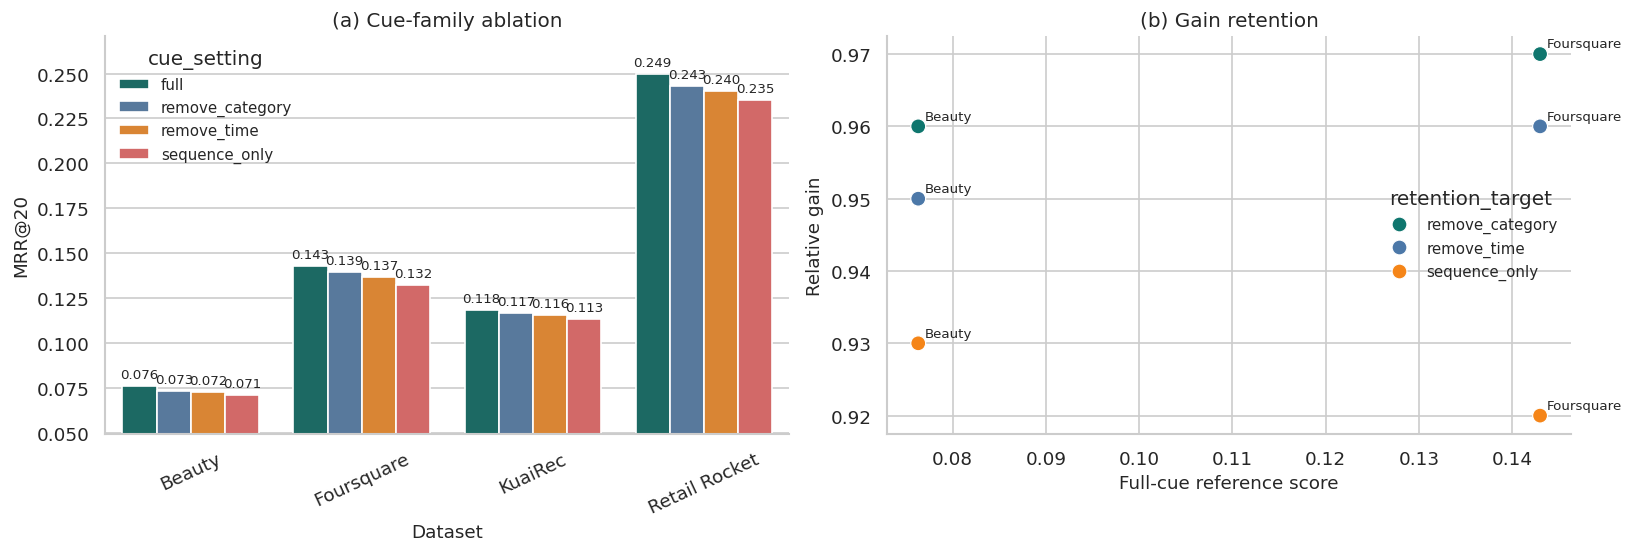

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), constrained_layout=True)
grouped_barplot(
    ablation_df,
    x="dataset",
    hue="cue_setting",
    y="value",
    ax=axes[0],
    title="(a) Cue-family ablation",
    ylabel="MRR@20",
    xlabel="Dataset",
    rotate=25,
)
scatterplot_with_annotations(
    retention_df,
    x="reference_value",
    y="relative_gain",
    hue="retention_target",
    annotate_column="dataset",
    ax=axes[1],
    title="(b) Gain retention",
    ylabel="Relative gain",
    xlabel="Full-cue reference score",
)
saved_paths = export_figure(fig, "04_cue_ablation", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()
